# 01. 탐색적 데이터 분석 (EDA)

**나무 묘목 생존 예측** 프로젝트의 첫 단계로, 원본 데이터를 탐색한다.

이 노트북의 목표
1. 데이터 구조와 각 변수의 의미 파악
2. 결측치·이상치·라벨 정의 확인
3. 어떤 요인이 생존과 관련 있는지 탐색
4. **다음 단계(전처리·모델링)에서 주의할 지점**을 미리 짚는다 — 특히 데이터 누수 가능성

---

### 데이터셋
- 출처: [Kaggle - Tree Survival Prediction](https://www.kaggle.com/datasets/yekenot/tree-survival-prediction/data)
- 규모: 2,783 행 × 24 열
- 각 행 = 심어진 묘목 한 그루의 관측 기록

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform

# 한글 폰트 (OS별)
if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", font=rcParams["font.family"])
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("../data/raw/Tree_Data.csv")
print("shape:", df.shape)
df.head()

shape: (2783, 24)


,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,Heterospecific,EMF,EMF,5/25/18,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,Heterospecific,EMF,AMF,5/31/18,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN


## 1. 변수 설명

| 컬럼 | 의미 | 유형 |
|------|------|------|
| `Species` | 묘목의 수종 | 범주 (4종) |
| `Light_ISF` / `Light_Cat` | 받는 빛의 양(연속) / 세기 등급(범주) | 연속 / 범주 |
| `Soil` | 토양의 출처(어떤 나무 밑 흙인지) | 범주 (7종) |
| `Sterile` | 토양 살균 여부 | 범주 (2) |
| `Conspecific` | 토양-묘목 관계 (동종/이종/살균) | 범주 (3) |
| `Myco` | 묘목에서 발견된 균근 타입 | 범주 (AMF/EMF) |
| `SoilMyco` | 토양에서 발견된 균근 타입 | 범주 (AMF/EMF/Sterile) |
| `AMF` / `EMF` | 균근균 감염 비율(%) | 연속 |
| `Phenolics` / `Lignin` / `NSC` | 식물 내 화학 성분 | 연속 |
| `PlantDate` / `Time` | 식재일 / 사건(사망·관측종료) 발생 시각 | 날짜 / 연속 |
| `Event` / `Harvest` / `Alive` | 사망 여부 / 수확 여부 / 생존 표시 | 상태 플래그 |
| `No, Plot, Subplot, Core, Census, Adult` | 실험 관리용 식별자 | 식별자 |

`Event`, `Harvest`, `Alive` 세 컬럼이 하나의 결과(묘목이 어떻게 됐는지)를 나눠 담고 있다. 이를 하나의 상태 라벨로 합쳐야 한다.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           2783 non-null   int64  
 1   Plot         2783 non-null   int64  
 2   Subplot      2783 non-null   object 
 3   Species      2783 non-null   object 
 4   Light_ISF    2783 non-null   float64
 5   Light_Cat    2783 non-null   object 
 6   Core         2783 non-null   int64  
 7   Soil         2783 non-null   object 
 8   Adult        2783 non-null   object 
 9   Sterile      2783 non-null   object 
 10  Conspecific  2783 non-null   object 
 11  Myco         2783 non-null   object 
 12  SoilMyco     2783 non-null   object 
 13  PlantDate    2783 non-null   object 
 14  AMF          2783 non-null   float64
 15  EMF          1283 non-null   float64
 16  Phenolics    2783 non-null   float64
 17  Lignin       2783 non-null   float64
 18  NSC          2783 non-null   float64
 19  Census

## 2. 결측치 확인

In [4]:
na = df.isna().sum()
print(na[na > 0])

EMF        1500
Event         1
Harvest    2079
Alive      2292
dtype: int64


- `EMF` 결측 1,500개: 균이 검출되지 않은 경우로 보임 → 0으로 채우는 것이 자연스럽다.
- `Harvest`(2,079), `Alive`(2,292) 결측: 결측이 아니라 **"해당 상태가 아님"을 의미하는 플래그**다. (수확된 개체만 Harvest='X')
- `Event` 결측 1개: 라벨을 만들 수 없는 행 → 제거 대상.

## 3. 라벨 정의: 세 플래그를 하나의 상태로 통합

- `Event == 1` → **사망(Dead, 0)**
- `Harvest == 'X'` → **수확(Harvested, 1)** — 실험자가 의도적으로 뽑아낸 개체
- `Alive == 'X'` → **생존(Alive, 2)** — 관측 종료까지 살아남음

In [5]:
d = df.copy()
d["Status"] = np.nan
d.loc[d["Event"] == 1, "Status"] = 0      # Dead
d.loc[d["Harvest"] == "X", "Status"] = 1  # Harvested
d.loc[d["Alive"] == "X", "Status"] = 2    # Alive

d = d.dropna(subset=["Status"]).copy()   # Event 결측 1행 제거
d["Status"] = d["Status"].astype(int)

status_name = {0: "Dead", 1: "Harvested", 2: "Alive"}
vc = d["Status"].value_counts().sort_index()
print(vc.rename(index=status_name))
print(f"\n총 {len(d)}행")

Status
Dead         1587
Harvested     704
Alive         491
Name: count, dtype: int64

총 2782행


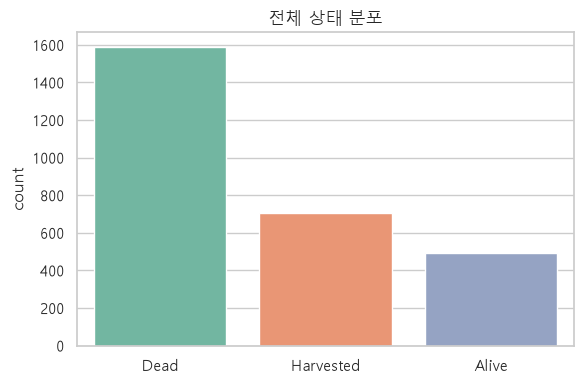

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
order = [0, 1, 2]
sns.countplot(x="Status", data=d, order=order, hue="Status",
              palette="Set2", legend=False, ax=ax)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([status_name[i] for i in order])
ax.set_title("전체 상태 분포")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 4. 핵심 경고: `Time`은 결과가 정해진 뒤 기록된 값

`Time`은 "사건(사망 또는 관측 종료)이 발생한 시각"이다. 상태별로 `Time` 분포를 보면 문제가 보인다.

In [7]:
print(d.groupby("Status")["Time"].describe()[["count","mean","std","min","max"]]
        .rename(index=status_name))

            count        mean        std    min    max
Status                                                
Dead       1587.0   47.004096  14.279385   14.0  115.5
Harvested   704.0   24.763494   0.924129   24.5   28.0
Alive       491.0  115.500000   0.000000  115.5  115.5


상태별 `Time`이 거의 완벽하게 갈린다.
- **생존(2)**: 전부 `Time = 115.5` (관측 끝까지 살아남음)
- **수확(1)**: 거의 전부 `Time ≈ 24.5` (초기에 의도적으로 뽑음)
- **사망(0)**: 14~115.5로 분산

즉 `Time`은 **결과를 알고 난 뒤에 기록되는 값**이다. 이를 예측 피처로 쓰면 "정답을 보고 정답을 맞히는" 데이터 누수가 된다. 아래에서 정량적으로 확인한다.

In [8]:
# 수확(1) 제외, 생존(2) vs 사망(0) 이진 문제로 단순화
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

b = d[d["Status"].isin([0, 2])].copy()
b["Survived"] = (b["Status"] == 2).astype(int)

clf = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
acc = cross_val_score(clf, b[["Time"]], b["Survived"], cv=5).mean()
print(f"'Time' 단 하나로 생존/사망 분류 (깊이1 트리, 5-fold): 정확도 {acc:.4f}")
print(f"기준(생존율): {b['Survived'].mean():.3f}")

'Time' 단 하나로 생존/사망 분류 (깊이1 트리, 5-fold): 정확도 0.9995
기준(생존율): 0.236


**`Time` 하나만으로 99.9% 정확도.** 이건 모델이 똑똑한 게 아니라, 답을 그대로 피처로 넣은 것이다.

> ✅ 결론: 다음 전처리 단계에서 **`Time`, `Event`, `Harvest`, `Alive` 같은 결과 파생 컬럼은 분류 피처에서 제외**해야 한다.
> (단, 뒤에서 다룰 *생존 분석*에서는 `Time`을 예측 대상(생존 시간)으로 쓰므로 정당하다.)

## 5. 생존과 관련된 요인 탐색

이제 누수 컬럼을 뺀 상태에서, **실제로 생존에 영향을 주는 요인**을 찾는다.
분석은 수확(1)을 제외한 **생존(2) vs 사망(0)** 이진 기준으로 본다. (수확은 실험자 개입이라 생존 요인 분석에서 제외)

In [9]:
print(f"분석 대상: {len(b)}행, 전체 생존율 {b['Survived'].mean():.1%}")

분석 대상: 2078행, 전체 생존율 23.6%


### 5-1. 균근(Mycorrhizae) 타입 — 가장 강한 신호

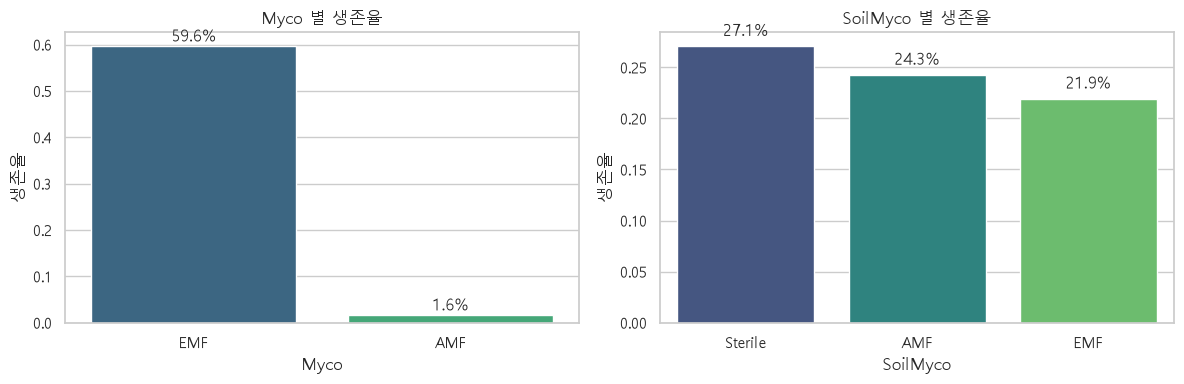

          mean  count
Myco                 
AMF   0.016279   1290
EMF   0.596447    788


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Myco", "SoilMyco"]):
    g = b.groupby(col)["Survived"].mean().sort_values(ascending=False)
    sns.barplot(x=g.index, y=g.values, hue=g.index,
                palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{col} 별 생존율")
    ax.set_ylabel("생존율")
    for i, v in enumerate(g.values):
        ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

print(b.groupby("Myco")["Survived"].agg(["mean", "count"]))

**묘목의 균근 타입(`Myco`)이 생존을 가장 강하게 가른다.**
- AMF 감염 묘목: 생존율 약 1.6%
- EMF 감염 묘목: 생존율 약 59.6%

EMF(외생균근)와 공생하는 묘목이 압도적으로 잘 산다. 반면 토양의 균근(`SoilMyco`)은 차이가 작다 → 중요한 건 "토양에 뭐가 있냐"보다 "묘목이 어떤 균과 공생하냐"다.

### 5-2. 수종(Species)

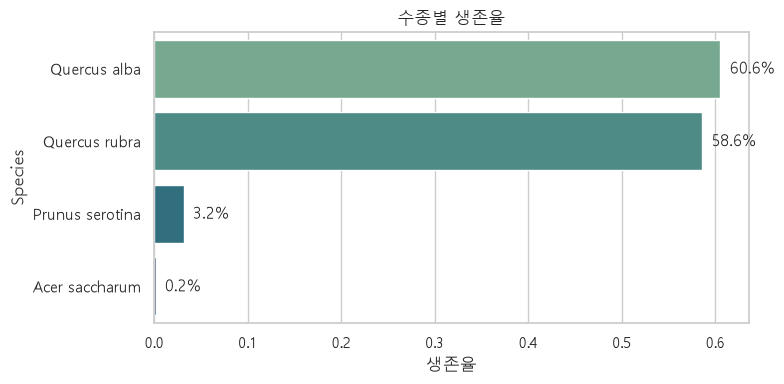

In [11]:
g = b.groupby("Species")["Survived"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=g.values, y=g.index, hue=g.index,
            palette="crest", legend=False, ax=ax)
ax.set_title("수종별 생존율")
ax.set_xlabel("생존율")
for i, v in enumerate(g.values):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.show()

참나무류(*Quercus alba* 60.6%, *Quercus rubra* 58.6%)는 잘 살고, *Acer saccharum*(0.2%)·*Prunus serotina*(3.2%)는 거의 죽는다. 수종 자체가 생존의 큰 요인이다.

> 참고: 참나무류는 주로 EMF와, 단풍/벚나무류는 주로 AMF와 공생한다. 즉 `Species`와 `Myco`는 강하게 얽혀 있다.

### 5-3. 화학 성분 (Phenolics / Lignin / NSC)

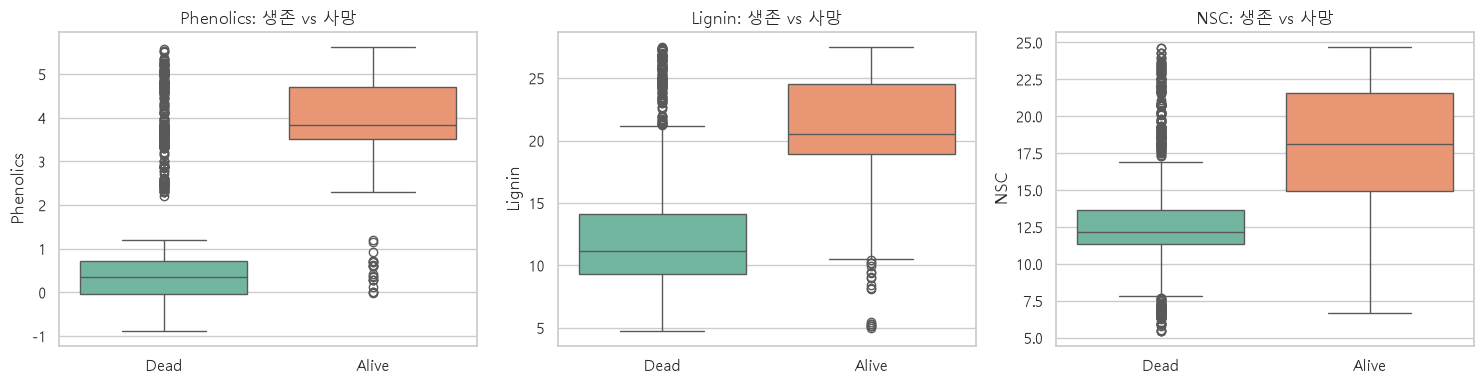

          Phenolics     Lignin        NSC
Survived                                 
0          0.948563  12.701569  12.688318
1          3.881976  21.076619  18.003992


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Phenolics", "Lignin", "NSC"]):
    sns.boxplot(x="Survived", y=col, data=b, hue="Survived",
                palette="Set2", legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Dead", "Alive"])
    ax.set_title(f"{col}: 생존 vs 사망")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print(b.groupby("Survived")[["Phenolics", "Lignin", "NSC"]].mean())

세 화학 성분 모두 생존 개체에서 뚜렷하게 높다 (특히 Phenolics: 생존 3.88 vs 사망 0.95). 방어·구조 물질이 많은 묘목이 잘 산다.

단, `Phenolics`에는 음수값이 존재한다(측정 특성상 극소 함유량에서 발생). 다음 전처리에서 보정이 필요하다.

In [13]:
neg = (df["Phenolics"] < 0).sum()
print(f"Phenolics 음수값 개수: {neg} / {len(df)}  (최솟값 {df['Phenolics'].min()})")

Phenolics 음수값 개수: 506 / 2783  (최솟값 -1.35)


### 5-4. 조도(Light)와 연속 변수 상관관계

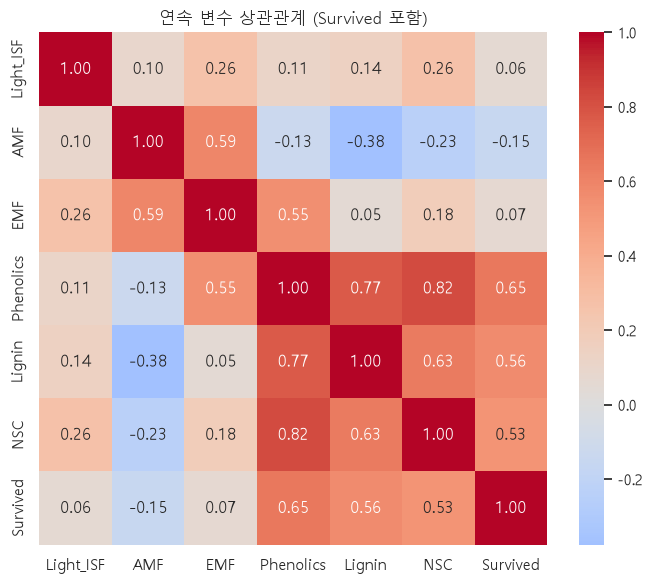

In [14]:
num_cols = ["Light_ISF", "AMF", "EMF", "Phenolics", "Lignin", "NSC", "Survived"]
corr = b[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("연속 변수 상관관계 (Survived 포함)")
plt.tight_layout()
plt.show()

- `Phenolics`, `Lignin`, `NSC`는 서로 양의 상관 (식물 생리상 함께 움직임).
- 이 화학 성분들이 `Survived`와도 양의 상관을 보인다.
- `Light_ISF`(조도)는 생존과의 선형 상관이 약하다 → 단독 영향은 제한적.

## 6. EDA 요약

| 발견 | 내용 | 다음 단계 반영 |
|------|------|----------------|
| **데이터 누수** | `Time`만으로 생존을 99.9% 분류 | 분류에서 결과 파생 컬럼(`Time/Event/Harvest/Alive`) 제외 |
| 균근 타입 | `Myco`=EMF일 때 생존율 급상승 (1.6%→59.6%) | 핵심 피처 |
| 수종 | 참나무류 생존율 높음 | 핵심 피처 |
| 화학 성분 | Phenolics/Lignin/NSC 높을수록 생존 | 피처 유지, Phenolics 음수 보정 |
| Phenolics 음수 | 506개 (극소 함유량) | 전처리에서 보정 |
| 결측치 | EMF는 0, Event 결측 1행 제거 | 전처리에서 처리 |

다음 노트북(`02_preprocessing`)에서 위 사항을 반영해 모델링용 데이터를 만든다.